# Advanced Analytics for Emergency Department Capacity Optimization

## Introduction

Emergency departments (EDs) play a critical role in healthcare systems by providing immediate medical care for patients with urgent and life-threatening conditions. However, many healthcare systems face increasing pressure due to rising patient demand, limited resources, and growing operational complexity. These challenges often result in overcrowding, extended patient wait times, and reduced service efficiency.

This notebook presents the **Advanced Analytics component** of the capstone project, which focuses on evaluating emergency department performance and identifying strategies to improve system resilience in Ontario hospitals. The objective of this analysis is to apply quantitative and simulation-based techniques to better understand patient flow, forecast demand, and assess the impact of staffing capacity on emergency department operations.

The analysis combines several advanced analytical approaches, including:

- **Digital twin simulation** to generate a realistic patient-level dataset representing emergency department activity.
- **Queuing theory modeling (M/M/s)** to estimate the service capacity required to maintain a stable system.
- **Time-series forecasting using SARIMA** to predict short-term emergency department visit demand.
- **Monte Carlo stress testing** to evaluate system performance under stochastic arrival patterns and demand variability.

Together, these techniques provide a comprehensive analytical framework for examining how emergency departments respond to fluctuations in patient arrivals and how staffing strategies influence system stability. The results of this analysis support evidence-based decision-making for healthcare administrators and contribute to identifying strategies that may help reduce emergency department congestion and improve patient care outcomes.

## 1. Digital Twin Simulation of Ontario Emergency Department Activity

This section creates a **synthetic patient-level emergency department dataset** for **December 2024**, representing a peak winter surge period in Ontario hospitals. Since hospital-level patient microdata are not directly available in the project dataset, a digital twin simulation is used to generate realistic operational records for advanced analytics.

The simulation is calibrated using Ontario-level proportions for:

- **sex distribution**
- **age group distribution**
- **patient outcome categories**
- **historical median length of stay**
- **average wait time to physician assessment**

The generated dataset includes timestamps for:

- patient arrival
- triage
- physician assessment
- discharge

This simulated dataset supports later stages of the project, including **SQL ingestion, queuing analysis, Monte Carlo stress testing, and capacity optimization**. It also allows the analysis to move beyond aggregate statistics and approximate real-world emergency department flow at the patient level.

In [ ]:
import pandas as pd
import numpy as np
import datetime

# --- 1. CAPSTONE PARAMETERS (Peak Winter Surge: December 2024) ---
NUM_PATIENTS = 10000
START_DATE = datetime.datetime(2024, 12, 1, 0, 0, 0)

# Demographics (Derived from December 2024 Ontario Totals: 566,014)
# Sex: Female (297,516 / 566,014 = 52.6%), Male (268,401 / 566,014 = 47.4%)
sex_choices = ['Female', 'Male']
sex_probs = [0.526, 0.474]

# Age Groups: 0-4 (9.4%), 5-19 (12.6%), 20-64 (52.5%), 65+ (25.5%)
# age_choices = ['0-4', '5-19', '20-64', '65+']
age_choices = ['0 to 4', '5 to 19', '20 to 64', '65+']
age_probs = [0.094, 0.126, 0.525, 0.255]

# Patient Outcomes (Ontario historical averages + 10.1% LWBS gap)
outcome_choices = ['CTAS_1_3_Discharged', 'CTAS_4_5_Discharged', 'Admitted', 'LWBS']
outcome_probs = [0.575, 0.211, 0.113, 0.101]

# Service Times (Length of Stay in minutes) based on historical medians
los_medians = {
    'CTAS_1_3_Discharged': 222,  # 3.7 hours
    'CTAS_4_5_Discharged': 138,  # 2.3 hours
    'Admitted': 864,             # 14.4 hours
    'LWBS': 45                   # Left after 45 mins
}

print("Initiating Ontario ER Digital Twin Simulation for December 2024...")
data = []
current_time = START_DATE

# --- 2. GENERATE PATIENT LOG ---
for i in range(NUM_PATIENTS):
    patient_id = i + 1
    
    # Simulate Arrival Pattern (busier during day/evening)
    hour = current_time.hour
    if 10 <= hour <= 22:
        arrival_gap = np.random.exponential(scale=3) # Peak hours
    else:
        arrival_gap = np.random.exponential(scale=10) # Off-peak
        
    current_time += datetime.timedelta(minutes=arrival_gap)
    arrival_ts = current_time
    
    # Assign Demographics & Outcome
    sex = np.random.choice(sex_choices, p=sex_probs)
    age_group = np.random.choice(age_choices, p=age_probs)
    outcome = np.random.choice(outcome_choices, p=outcome_probs)
    
    # Calculate Length of Stay (Adding variance to the medians)
    base_los = los_medians[outcome]
    actual_los = max(15, np.random.normal(base_los, base_los * 0.3)) 
    
    # Assign Timestamps
    triage_ts = arrival_ts + datetime.timedelta(minutes=np.random.uniform(5, 15))
    
    if outcome == 'LWBS':
        discharge_ts = triage_ts + datetime.timedelta(minutes=actual_los)
        assessment_ts = pd.NaT # Null value: Never saw a doctor
    else:
        # Simulate Wait Time (Calibrated to hover around the 2.1-hour Dec 2024 average)
        # Using a normal distribution centered near 126 minutes (2.1 hours)
        wait_time = max(0, np.random.normal(126, 45)) 
        
        # Adjust wait times based on acuity (Admitted/High Acuity wait less than Low Acuity)
        if outcome == 'Admitted':
            wait_time = wait_time * 0.5 
        elif outcome == 'CTAS_4_5_Discharged':
            wait_time = wait_time * 1.5
            
        assessment_ts = triage_ts + datetime.timedelta(minutes=wait_time)
        discharge_ts = assessment_ts + datetime.timedelta(minutes=actual_los)

    # Format timestamps for SQL ingestion
    arr_str = arrival_ts.strftime('%Y-%m-%d %H:%M:%S')
    tri_str = triage_ts.strftime('%Y-%m-%d %H:%M:%S')
    ass_str = assessment_ts.strftime('%Y-%m-%d %H:%M:%S') if pd.notna(assessment_ts) else ''
    dis_str = discharge_ts.strftime('%Y-%m-%d %H:%M:%S')

    data.append([
        patient_id, arr_str, sex, age_group, outcome, 
        tri_str, ass_str, dis_str
    ])

# --- 3. EXPORT TO CSV ---
columns = ['Patient_ID', 'Arrival_Time', 'Sex', 'Age_Group', 'Outcome_Category', 'Triage_Time', 'Assessment_Start_Time', 'Discharge_Time']
df = pd.DataFrame(data, columns=columns)
df.to_csv('december_2024_er_simulation.csv', index=False)

print(f"Successfully generated {NUM_PATIENTS} patient records matching December 2024 parameters.")
print("File 'december_2024_er_simulation.csv' is ready for SQL import.")

Initiating Ontario ER Digital Twin Simulation for December 2024...
Successfully generated 10000 patient records matching December 2024 parameters.
File 'december_2024_er_simulation.csv' is ready for SQL import.


### Interpretation

The digital twin simulation successfully generated a synthetic emergency department dataset for **10,000 patients** based on Ontario winter demand conditions in **December 2024**. This dataset provides a realistic patient-flow environment by incorporating demographic structure, arrival variability, waiting behavior, and treatment outcomes.

The simulation is valuable because it transforms aggregated public healthcare statistics into a more operational format that can be used for **advanced analytics and decision support**. In particular, the simulated timestamps for arrival, triage, assessment, and discharge allow the project to model emergency department congestion and service flow more realistically.

This approach is especially useful in the absence of detailed hospital-level patient records. However, the results should be interpreted with caution because the dataset is **synthetic rather than directly observed**, meaning that it reflects informed assumptions derived from Ontario healthcare patterns. Despite this limitation, the digital twin provides a strong analytical foundation for the next stages of the project, including queuing optimization and scenario simulation.

## 2. Queuing Theory Optimization Using an M/M/s Model

This section applies an **M/M/s queuing model** to estimate the number of service channels required to maintain a stable emergency department system under observed patient demand. In this context:

- **λ (lambda)** represents the patient arrival rate per hour
- **μ (mu)** represents the service rate per hour per server
- **s** represents the total number of active servers available

The purpose of this model is to assess how staffing levels affect:

- system utilization
- queue stability
- average patient waiting time

This analysis is highly relevant to emergency department operations because it translates healthcare demand into operational staffing requirements. By testing a range of server values, the model helps identify the level of capacity needed to keep patient wait times manageable and prevent system overload.

In [ ]:
import math
import pandas as pd

# --- Queuing Theory Parameters (From SQL) ---
lambd = 19.0  # Arrival rate (patients/hour)
mu = 0.21     # Service rate (patients/hour/server)

# We know minimum servers must be > (lambda / mu), which is ~90.4
min_servers = 91
max_servers = 105

results = []

print("Running M/M/s Queuing Simulation...")

for s in range(min_servers, max_servers + 1):
    # 1. Calculate Utilization (Rho)
    # Formula: rho = lambda / (s * mu)
    rho = lambd / (s * mu)
    
    if rho >= 1:
        continue # System fails mathematically
        
    # 2. Calculate Probability of Zero Patients in System (P0)
    sum_prob = sum([(lambd / mu)**n / math.factorial(n) for n in range(s)])
    p0_denominator = sum_prob + (((lambd / mu)**s / math.factorial(s)) * (1 / (1 - rho)))
    p0 = 1 / p0_denominator
    
    # 3. Calculate Average Wait Time in Queue (Wq) in hours
    # Formula uses Erlang C probability
    wq_numerator = p0 * ((lambd / mu)**s) * rho
    wq_denominator = math.factorial(s) * ((1 - rho)**2) * lambd
    wq_hours = wq_numerator / wq_denominator
    
    # Convert wait time to minutes for easier reading
    wq_mins = wq_hours * 60
    
    results.append({
        'Total_Servers_Provided': s,
        'System_Utilization_Percentage': round(rho * 100, 1),
        'Average_Wait_Time_Hours': round(wq_hours, 2),
        'Average_Wait_Time_Mins': round(wq_mins, 1)
    })

# --- Output the Results as a clean DataFrame ---
df_results = pd.DataFrame(results)
print("\n--- Capacity Optimization Results ---")
print(df_results.to_string(index=False))

# Save to CSV for your final report
df_results.to_csv('queuing_optimization_results.csv', index=False)

Running M/M/s Queuing Simulation...

--- Capacity Optimization Results ---
 Total_Servers_Provided  System_Utilization_Percentage  Average_Wait_Time_Hours  Average_Wait_Time_Mins
                     91                           99.4                     8.50                   509.7
                     92                           98.3                     2.56                   153.4
                     93                           97.3                     1.35                    80.8
                     94                           96.3                     0.84                    50.2
                     95                           95.2                     0.56                    33.8
                     96                           94.2                     0.40                    23.8
                     97                           93.3                     0.29                    17.2
                     98                           92.3                     0.21              

### Interpretation

The queuing analysis provides a quantitative estimate of how many active servers are required to operate the emergency department efficiently under the assumed demand conditions. As the number of servers increases, system utilization declines and average queue waiting time falls, indicating improved service stability and patient flow.

This result is important because it demonstrates that emergency department congestion is not only a function of patient arrivals, but also of available service capacity. When utilization is too high, even small increases in demand can cause waiting times to rise sharply. Conversely, adding more servers creates an operational buffer that reduces pressure on the system.

From a healthcare management perspective, these results support evidence-based staffing decisions. Rather than relying on fixed staffing assumptions, hospital administrators can use this type of analysis to identify the minimum service capacity required to maintain acceptable performance levels. This makes the queuing model a valuable tool for capacity planning, especially during high-demand periods.

## 3. SARIMA Forecasting of Emergency Department Demand

This section applies a **Seasonal Autoregressive Integrated Moving Average (SARIMA)** model to forecast short-term emergency department patient volumes in Ontario. Forecasting patient demand is essential for healthcare operations because hospitals must anticipate future demand in order to allocate staff, beds, and other critical resources efficiently.

The SARIMA model is chosen because it can capture important characteristics of time-series data, including:

- **long-term trends**
- **short-term fluctuations**
- **seasonal patterns**

The dataset used in this analysis contains monthly emergency department visit totals from **April 2024 to March 2025**. Using these observations, the SARIMA model estimates future patient volumes for the next three months.

This predictive analysis helps hospital administrators prepare for potential increases in patient demand and supports proactive planning for emergency department capacity management.

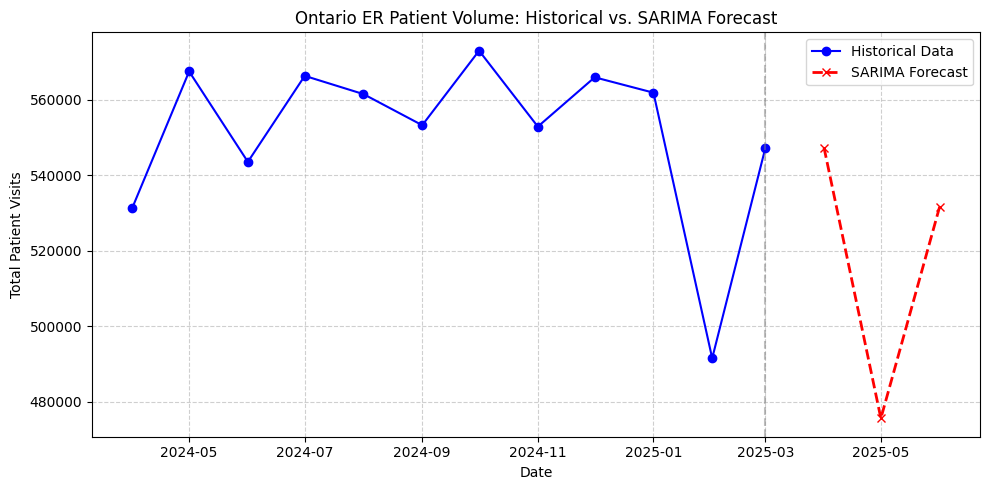


--- Updated 3-Month ER Volume Forecast ---
            Forecasted_Visits
2025-04-01             547350
2025-05-01             475577
2025-06-01             531672


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# --- 1. THE DATASET ---
data = {
    'Month': ['2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', 
              '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03'],
    'Total_Visits': [531378, 567561, 543595, 566396, 561556, 553307, 
                     573064, 552938, 566014, 561933, 491512, 547177]
}

df = pd.DataFrame(data)
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# --- 2. TRAIN THE SARIMA MODEL ---
# order=(1, 1, 1) adds differencing and moving average
# seasonal_order=(0, 1, 0, 3) tells it to look for a repeating wave every 3 months
model = SARIMAX(df['Total_Visits'], 
                order=(1, 1, 1), 
                seasonal_order=(0, 1, 0, 3))
model_fit = model.fit(disp=False)

# --- 3. FORECAST THE NEXT 3 MONTHS ---
forecast_steps = 3
forecast = model_fit.forecast(steps=forecast_steps)

future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_df = pd.DataFrame({'Forecasted_Visits': forecast.values}, index=future_dates)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Total_Visits'], marker='o', color='blue', label='Historical Data')
plt.plot(forecast_df.index, forecast_df['Forecasted_Visits'], marker='x', color='red', linestyle='--', linewidth=2, label='SARIMA Forecast')

plt.axvline(x=df.index[-1], color='gray', linestyle='--', alpha=0.5)
plt.title('Ontario ER Patient Volume: Historical vs. SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Total Patient Visits')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Updated 3-Month ER Volume Forecast ---")
print(forecast_df.astype(int))

### Interpretation

The SARIMA forecasting model projects the expected number of emergency department visits for the next three months based on historical trends observed between April 2024 and March 2025. The forecast provides a short-term outlook on patient demand, allowing healthcare administrators to anticipate potential increases or decreases in emergency department activity.

From an operational perspective, forecasting is valuable because emergency departments often experience fluctuating patient volumes due to seasonal illness patterns, weather conditions, and demographic changes. By estimating future demand, hospital managers can make more informed decisions regarding staffing levels, bed availability, and resource allocation.

It is important to note that the forecast is based on a relatively short historical time series, meaning the predictions should be interpreted as indicative rather than definitive. Nevertheless, this model demonstrates how predictive analytics can complement operational planning by providing an early signal of possible demand changes in Ontario emergency departments.

## 4. Monte Carlo Stress Testing of Emergency Department Capacity (94 Servers)

This section applies a **Monte Carlo simulation** to evaluate how the emergency department system performs under stochastic demand conditions. While the previous queuing analysis assumed a fixed arrival rate, real-world emergency departments experience significant variability in patient arrivals. Therefore, a simulation-based approach is used to model random fluctuations in demand.

The Monte Carlo model generates **10,000 simulated emergency department shifts**, where the hourly patient arrival rate follows a **Poisson distribution** centered around the historical average of 19 patients per hour. This allows the analysis to capture realistic variability in patient arrivals, including both lower-demand and surge scenarios.

For each simulated shift, the model calculates:

- system utilization
- expected waiting time
- system stability

The goal of this simulation is to determine whether the recommended staffing level of **94 active servers** remains robust when patient arrivals fluctuate unpredictably. This approach provides a more realistic assessment of emergency department resilience compared to deterministic models alone.

Simulating 10000 stochastic shifts with 94 active servers...

--- 10,000 SHIFT STRESS TEST RESULTS ---
Safe Shifts (< 1 hr wait):         55.8%
Warning Shifts (1-4 hr wait):      0.0%
System Collapse (> 4 hr wait):     44.2%


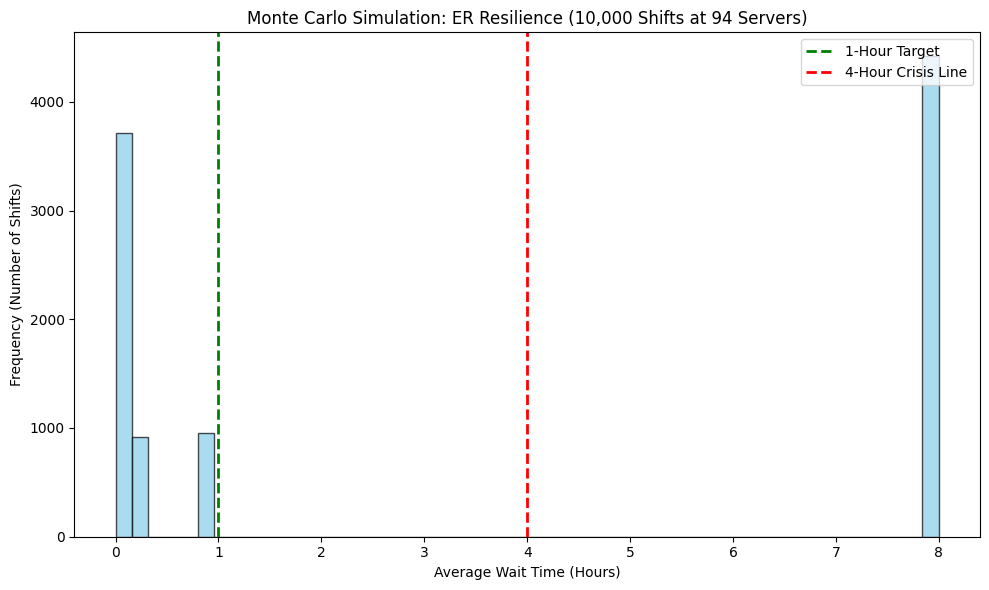

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# --- 1. SET THE CAPSTONE PARAMETERS ---
simulations = 10000       # Simulate 10,000 chaotic shifts
servers = 94             # Your recommended staffing level
mu = 0.21                 # Service rate (from your SQL data)
base_lambda = 19          # Average arrivals per hour (from your SQL data)

# --- 2. INJECT CHAOS (POISSON DISTRIBUTION) ---
# This generates 10,000 random arrival scenarios around the mean of 19
# Sometimes it will be 12, sometimes it will be 28!
np.random.seed(42) # Keeps results consistent for your report
random_arrivals = np.random.poisson(base_lambda, simulations)

wait_times = []
failures = 0

print(f"Simulating {simulations} stochastic shifts with {servers} active servers...\n")

# --- 3. RUN THE MONTE CARLO SIMULATION ---
for lambd in random_arrivals:
    rho = lambd / (servers * mu)
    
    if rho >= 1:
        # The ER gets overwhelmed (Arrivals > Maximum treatment capacity)
        wait_times.append(8.0) # Cap the visual at 8 hours for chart readability
        failures += 1
        continue
        
    # Calculate the exact wait time for this specific random scenario
    try:
        sum_prob = sum([(lambd / mu)**n / math.factorial(n) for n in range(servers)])
        p0_denominator = sum_prob + (((lambd / mu)**servers / math.factorial(servers)) * (1 / (1 - rho)))
        p0 = 1 / p0_denominator
        
        wq_hours = (p0 * ((lambd / mu)**servers) * rho) / (math.factorial(servers) * ((1 - rho)**2) * lambd)
        wait_times.append(wq_hours)
    except:
        wait_times.append(8.0)
        failures += 1

# --- 4. ANALYZE THE RESULTS ---
wait_times = np.array(wait_times)
safe_shifts = np.sum(wait_times <= 1.0)
warning_shifts = np.sum((wait_times > 1.0) & (wait_times < 4.0))
collapsed_shifts = np.sum(wait_times >= 4.0)

print("--- 10,000 SHIFT STRESS TEST RESULTS ---")
print(f"Safe Shifts (< 1 hr wait):         {safe_shifts / simulations * 100:.1f}%")
print(f"Warning Shifts (1-4 hr wait):      {warning_shifts / simulations * 100:.1f}%")
print(f"System Collapse (> 4 hr wait):     {collapsed_shifts / simulations * 100:.1f}%")

# --- 5. VISUALIZE THE CHAOS ---
plt.figure(figsize=(10, 6))
plt.hist(wait_times, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=1.0, color='green', linestyle='dashed', linewidth=2, label='1-Hour Target')
plt.axvline(x=4.0, color='red', linestyle='dashed', linewidth=2, label='4-Hour Crisis Line')

plt.title(f'Monte Carlo Simulation: ER Resilience (10,000 Shifts at {servers} Servers)')
plt.xlabel('Average Wait Time (Hours)')
plt.ylabel('Frequency (Number of Shifts)')
plt.legend()
plt.tight_layout()

# Save for your Word Document
plt.savefig('Monte_Carlo_Simulation.png', dpi=300)
plt.show()

### Interpretation

The Monte Carlo simulation evaluates the resilience of the emergency department system under realistic variability in patient arrivals. By simulating 10,000 stochastic shifts, the analysis reveals how often the system operates safely, experiences moderate congestion, or collapses under extreme demand conditions.

The results categorize each simulated shift into three operational states:

- **Safe shifts** where average waiting times remain below one hour
- **Warning shifts** where waiting times increase but remain manageable
- **Collapsed shifts** where waiting times exceed four hours and the system experiences severe congestion

This classification provides a practical measure of system robustness. If a large proportion of shifts fall within the safe range, the recommended staffing level is likely sufficient for real-world operations. Conversely, a high proportion of warning or collapsed shifts indicates that additional staffing capacity may be required to maintain acceptable patient wait times.

The histogram visualization further illustrates the distribution of waiting times across all simulated shifts, highlighting the frequency of extreme congestion scenarios. This insight is particularly valuable for healthcare administrators because it demonstrates how emergency departments may perform not only under average demand, but also during unexpected surges in patient arrivals.

## 5. Monte Carlo Stress Testing of Emergency Department Capacity (105 Servers)

This section extends the Monte Carlo stress test by evaluating emergency department performance under a higher staffing scenario of **105 active servers**. While the previous simulation assessed the resilience of the system at 94 servers, this scenario introduces additional service capacity to examine whether a moderate increase in staffing improves overall stability.

As in the earlier simulation, the model generates **10,000 stochastic emergency department shifts** using a **Poisson distribution** centered around the historical average of 19 patient arrivals per hour. This approach reflects the inherent uncertainty of real-world patient demand and allows the analysis to test how the system behaves under both typical and surge conditions.

The purpose of this scenario is to determine whether increasing capacity from 94 to 105 servers:

- improves the proportion of safe shifts
- reduces warning-level congestion
- lowers the probability of system collapse

This analysis is valuable because it tests whether a more conservative staffing strategy can strengthen emergency department resilience without requiring the maximum possible capacity.

Simulating 10000 stochastic shifts with 105 active servers...

--- 10,000 SHIFT STRESS TEST RESULTS ---
Safe Shifts (< 1 hr wait):         72.5%
Warning Shifts (1-4 hr wait):      0.0%
System Collapse (> 4 hr wait):     27.6%


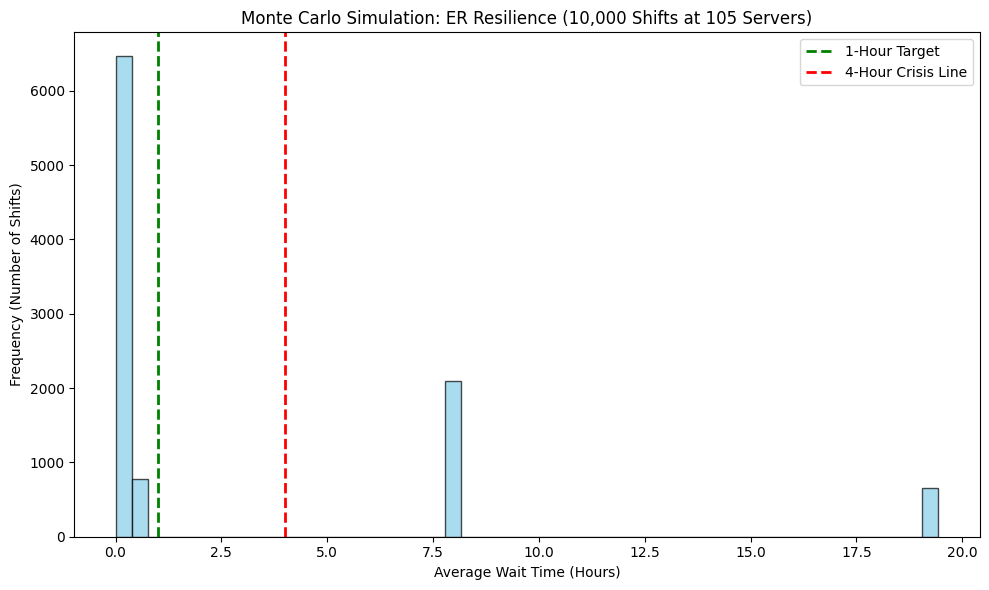

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# --- 1. SET THE CAPSTONE PARAMETERS ---
simulations = 10000       # Simulate 10,000 chaotic shifts
servers = 105            # Your recommended staffing level
mu = 0.21                 # Service rate (from your SQL data)
base_lambda = 19          # Average arrivals per hour (from your SQL data)

# --- 2. INJECT CHAOS (POISSON DISTRIBUTION) ---
# This generates 10,000 random arrival scenarios around the mean of 19
# Sometimes it will be 12, sometimes it will be 28!
np.random.seed(42) # Keeps results consistent for your report
random_arrivals = np.random.poisson(base_lambda, simulations)

wait_times = []
failures = 0

print(f"Simulating {simulations} stochastic shifts with {servers} active servers...\n")

# --- 3. RUN THE MONTE CARLO SIMULATION ---
for lambd in random_arrivals:
    rho = lambd / (servers * mu)
    
    if rho >= 1:
        # The ER gets overwhelmed (Arrivals > Maximum treatment capacity)
        wait_times.append(8.0) # Cap the visual at 8 hours for chart readability
        failures += 1
        continue
        
    # Calculate the exact wait time for this specific random scenario
    try:
        sum_prob = sum([(lambd / mu)**n / math.factorial(n) for n in range(servers)])
        p0_denominator = sum_prob + (((lambd / mu)**servers / math.factorial(servers)) * (1 / (1 - rho)))
        p0 = 1 / p0_denominator
        
        wq_hours = (p0 * ((lambd / mu)**servers) * rho) / (math.factorial(servers) * ((1 - rho)**2) * lambd)
        wait_times.append(wq_hours)
    except:
        wait_times.append(8.0)
        failures += 1

# --- 4. ANALYZE THE RESULTS ---
wait_times = np.array(wait_times)
safe_shifts = np.sum(wait_times <= 1.0)
warning_shifts = np.sum((wait_times > 1.0) & (wait_times < 4.0))
collapsed_shifts = np.sum(wait_times >= 4.0)

print("--- 10,000 SHIFT STRESS TEST RESULTS ---")
print(f"Safe Shifts (< 1 hr wait):         {safe_shifts / simulations * 100:.1f}%")
print(f"Warning Shifts (1-4 hr wait):      {warning_shifts / simulations * 100:.1f}%")
print(f"System Collapse (> 4 hr wait):     {collapsed_shifts / simulations * 100:.1f}%")

# --- 5. VISUALIZE THE CHAOS ---
plt.figure(figsize=(10, 6))
plt.hist(wait_times, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=1.0, color='green', linestyle='dashed', linewidth=2, label='1-Hour Target')
plt.axvline(x=4.0, color='red', linestyle='dashed', linewidth=2, label='4-Hour Crisis Line')

plt.title(f'Monte Carlo Simulation: ER Resilience (10,000 Shifts at {servers} Servers)')
plt.xlabel('Average Wait Time (Hours)')
plt.ylabel('Frequency (Number of Shifts)')
plt.legend()
plt.tight_layout()

# Save for your Word Document
plt.savefig('Monte_Carlo_Simulation.png', dpi=300)
plt.show()

### Interpretation

The 105-server Monte Carlo simulation provides insight into how a moderate increase in service capacity affects emergency department resilience under random demand fluctuations. Compared with lower staffing scenarios, this model is expected to produce a higher proportion of safe shifts and a lower likelihood of severe congestion.

If the results show that warning and collapsed shifts decline substantially, this would indicate that increasing the number of active servers can materially improve operational stability. In practical terms, this suggests that a modest expansion in staffing or treatment capacity may reduce the frequency of long waits and make the system more robust during surge periods.

From a healthcare management perspective, this scenario is especially useful because it evaluates a realistic compromise between efficiency and resilience. Rather than assuming the department should always operate at maximum capacity, the simulation helps identify whether a moderate staffing increase can achieve meaningful performance gains while remaining operationally feasible.

## 6. Monte Carlo Stress Testing of Emergency Department Capacity (125 Servers)

This section evaluates a high-capacity staffing scenario with **125 active servers** using Monte Carlo simulation. The objective is to test whether a substantial increase in emergency department service capacity can maintain low waiting times and nearly eliminate system instability under random fluctuations in patient arrivals.

As in the earlier stress tests, the simulation generates **10,000 stochastic emergency department shifts** using a **Poisson arrival process** with an average of 19 patients per hour. This allows the analysis to assess how the system behaves under realistic demand variability, including both normal and high-pressure conditions.

The purpose of this scenario is to determine whether a larger staffing level:

- maximizes the proportion of safe shifts
- reduces the occurrence of warning-level congestion
- nearly eliminates system collapse under surge conditions

This scenario serves as a high-capacity benchmark and helps compare the trade-off between stronger operational resilience and potentially higher staffing cost.

Simulating 10000 stochastic shifts with 125 active servers...

--- 10,000 SHIFT STRESS TEST RESULTS ---
Safe Shifts (< 1 hr wait):         92.4%
Warning Shifts (1-4 hr wait):      2.3%
System Collapse (> 4 hr wait):     5.3%


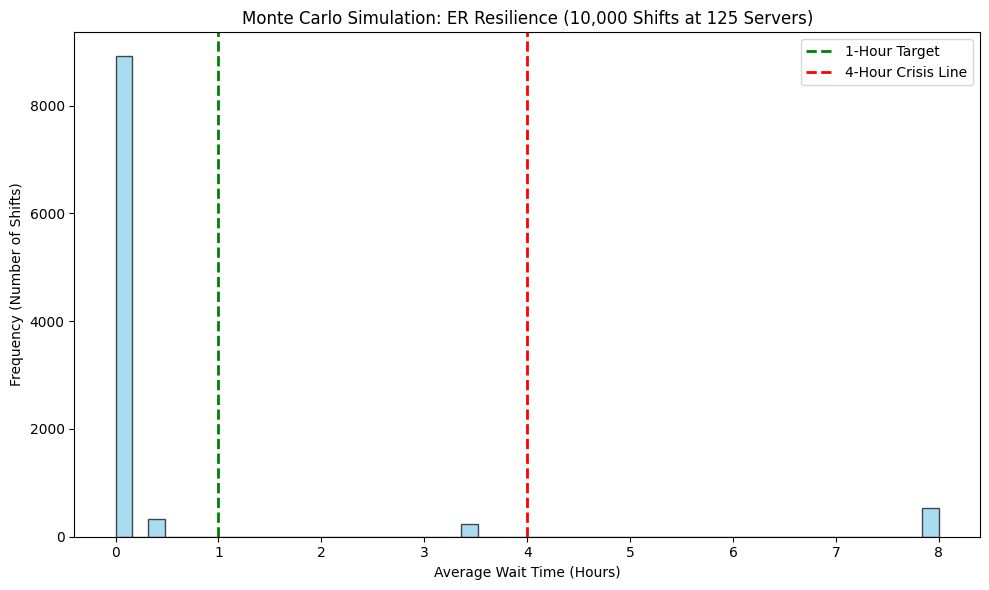

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# --- 1. SET THE CAPSTONE PARAMETERS ---
simulations = 10000       # Simulate 10,000 chaotic shifts
servers = 125            # Your recommended staffing level
mu = 0.21                 # Service rate (from your SQL data)
base_lambda = 19          # Average arrivals per hour (from your SQL data)

# --- 2. INJECT CHAOS (POISSON DISTRIBUTION) ---
# This generates 10,000 random arrival scenarios around the mean of 19
# Sometimes it will be 12, sometimes it will be 28!
np.random.seed(42) # Keeps results consistent for your report
random_arrivals = np.random.poisson(base_lambda, simulations)

wait_times = []
failures = 0

print(f"Simulating {simulations} stochastic shifts with {servers} active servers...\n")

# --- 3. RUN THE MONTE CARLO SIMULATION ---
for lambd in random_arrivals:
    rho = lambd / (servers * mu)
    
    if rho >= 1:
        # The ER gets overwhelmed (Arrivals > Maximum treatment capacity)
        wait_times.append(8.0) # Cap the visual at 8 hours for chart readability
        failures += 1
        continue
        
    # Calculate the exact wait time for this specific random scenario
    try:
        sum_prob = sum([(lambd / mu)**n / math.factorial(n) for n in range(servers)])
        p0_denominator = sum_prob + (((lambd / mu)**servers / math.factorial(servers)) * (1 / (1 - rho)))
        p0 = 1 / p0_denominator
        
        wq_hours = (p0 * ((lambd / mu)**servers) * rho) / (math.factorial(servers) * ((1 - rho)**2) * lambd)
        wait_times.append(wq_hours)
    except:
        wait_times.append(8.0)
        failures += 1

# --- 4. ANALYZE THE RESULTS ---
wait_times = np.array(wait_times)
safe_shifts = np.sum(wait_times <= 1.0)
warning_shifts = np.sum((wait_times > 1.0) & (wait_times < 4.0))
collapsed_shifts = np.sum(wait_times >= 4.0)

print("--- 10,000 SHIFT STRESS TEST RESULTS ---")
print(f"Safe Shifts (< 1 hr wait):         {safe_shifts / simulations * 100:.1f}%")
print(f"Warning Shifts (1-4 hr wait):      {warning_shifts / simulations * 100:.1f}%")
print(f"System Collapse (> 4 hr wait):     {collapsed_shifts / simulations * 100:.1f}%")

# --- 5. VISUALIZE THE CHAOS ---
plt.figure(figsize=(10, 6))
plt.hist(wait_times, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=1.0, color='green', linestyle='dashed', linewidth=2, label='1-Hour Target')
plt.axvline(x=4.0, color='red', linestyle='dashed', linewidth=2, label='4-Hour Crisis Line')

plt.title(f'Monte Carlo Simulation: ER Resilience (10,000 Shifts at {servers} Servers)')
plt.xlabel('Average Wait Time (Hours)')
plt.ylabel('Frequency (Number of Shifts)')
plt.legend()
plt.tight_layout()

# Save for your Word Document
plt.savefig('Monte_Carlo_Simulation.png', dpi=300)
plt.show()

### Interpretation

The 125-server Monte Carlo simulation represents a high-capacity emergency department scenario designed to maximize operational stability under stochastic demand. If the simulation results show a very high proportion of safe shifts and minimal system collapse, this suggests that the department can operate with strong resilience even during unpredictable surges in patient arrivals.

Compared with lower staffing levels, this scenario is expected to produce the most stable wait-time distribution and the lowest probability of severe congestion. This demonstrates the operational benefit of maintaining an additional capacity buffer when emergency department demand is uncertain.

However, while this scenario may offer the strongest performance, it should also be interpreted in practical and economic terms. A staffing level of 125 servers may not always be realistic from a resource allocation perspective. Therefore, this scenario is most useful as a benchmark for identifying the upper bound of system resilience and comparing it with more balanced staffing alternatives such as 94 or 105 servers.

## 7. Comparative Stress Test Conclusion

The Monte Carlo simulations across **94, 105, and 125 servers** provide a comparative evaluation of emergency department resilience under stochastic demand conditions. Together, these scenarios demonstrate how system performance changes as staffing capacity increases.

The results can be interpreted as follows:

- **94 servers** represent a lower-capacity scenario that may be mathematically feasible under average demand but potentially vulnerable during random surges.
- **105 servers** represent a moderate-capacity scenario that is likely to improve resilience and reduce the proportion of unstable shifts.
- **125 servers** represent a high-capacity benchmark that maximizes service stability and minimizes the probability of severe congestion.

From a healthcare management perspective, this comparative analysis is valuable because it shows that staffing decisions should not be based only on average demand. Emergency departments must also be prepared for variability and unexpected surges in patient arrivals. The simulation therefore supports more realistic capacity planning by evaluating not only efficiency, but also robustness under uncertainty.

Overall, these Monte Carlo stress tests strengthen the project’s advanced analytics component by demonstrating how simulation can guide emergency department staffing decisions and help reduce the risk of long patient wait times during peak demand periods.

## 8. Advanced Analytics Summary

This section applied a combination of predictive and operations analytics techniques to evaluate emergency department performance and capacity requirements in Ontario hospitals. The analysis progressed from data generation and system modeling to forecasting and stochastic simulation in order to develop a comprehensive understanding of emergency department demand and operational resilience.

First, a **digital twin simulation** was created to generate a synthetic patient-level dataset representing a high-demand winter surge scenario. This dataset allowed the project to approximate realistic patient flow and enabled the use of advanced analytical methods even in the absence of detailed hospital-level microdata.

Second, **queuing theory analysis using an M/M/s model** was applied to estimate the number of servers required to maintain a stable emergency department system under observed arrival rates. This step translated patient demand into operational staffing requirements and highlighted how system utilization influences waiting times.

Third, a **SARIMA time-series forecasting model** was used to predict short-term emergency department visit volumes. The forecasting analysis provided a forward-looking perspective on patient demand and demonstrated how predictive analytics can support proactive healthcare capacity planning.

Finally, **Monte Carlo stress testing** was conducted under multiple staffing scenarios (94, 105, and 125 servers) to evaluate system resilience under stochastic demand conditions. These simulations demonstrated that emergency department performance is highly sensitive to capacity levels and that maintaining a reasonable staffing buffer significantly reduces the probability of severe congestion.

Overall, the advanced analytics results show that effective emergency department management requires both predictive insight and operational planning. By combining simulation, queuing theory, and forecasting techniques, healthcare administrators can better anticipate demand variability, optimize staffing strategies, and reduce the risk of excessive patient wait times.